# Data Preprocessing Pipeline for PM2.5 Prediction Model

This notebook implements a comprehensive 7-phase preprocessing pipeline designed for machine learning model development:

**Phase 1:** Data Exploration & Profiling

**Phase 2:** Intelligent Missing Value Imputation

**Phase 3:** Feature Engineering (Temporal + Interaction Features)

**Phase 4:** Multi-Strategy Scaling (Group-Specific Approach)

**Phase 5:** Temporal Train/Val/Test Split (Prevents Data Leakage)

**Phase 6:** Correlation Analysis & Redundant Feature Removal

**Phase 7:** Quality Assurance & Overfitting Detection Setup

## Critical ML Principles Implemented:
- **Temporal Split:** Train/Val/Test split by date (not random) to respect causality
- **No Data Leakage:** Scalers and imputers fit ONLY on training data
- **Preserve Outliers:** Keep extreme values (important for air quality extremes)
- **Overfitting Detection:** Monitor train vs validation error gaps
- **TimeSeriesSplit:** For cross-validation during model training

## Setup: Import Libraries and Configure Paths

In [108]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# sklearn imports
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer

# Setup paths
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    base_dir = notebook_dir.parent
else:
    base_dir = notebook_dir

data_dir = base_dir / 'data'
output_dir = base_dir / 'preprocessed_data'
output_dir.mkdir(exist_ok=True)

print(f"Base directory: {base_dir}")
print(f"Data directory: {data_dir}")
print(f"Output directory: {output_dir}")

Base directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality
Data directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\data
Output directory: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\preprocessed_data


---
# PHASE 1: Data Exploration & Profiling

Load the merged dataset and explore its structure, missing values, and distributions.

In [109]:
# Load merged data
combined_file = data_dir / 'combined_gee_pm25.csv'
df = pd.read_csv(combined_file)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

Dataset shape: (41718, 15)

Column names and types:
date                    object
datetime_utc            object
id                       int64
latitude               float64
longitude              float64
temperature_celsius    float64
pressure_mb            float64
wind_u                 float64
wind_v                 float64
NO2                    float64
CO                     float64
O3                     float64
AOD                    float64
pm25                   float64
sensor_name             object
dtype: object

First few rows:


,date,datetime_utc,id,latitude,longitude,temperature_celsius,pressure_mb,wind_u,wind_v,NO2,CO,O3,AOD,pm25,sensor_name
0,2016-11-25,2016-11-25 00:00:00,1,38.788056,-0.697222,6.493180,946.288660,0.230240,0.735303,NaN,NaN,NaN,0.1110,2.750000,ONTINYENT
1,2016-11-25,2016-11-25 00:00:00,36,39.945278,-0.056389,9.251236,993.626994,0.783218,-0.592618,NaN,NaN,NaN,0.0220,11.666667,ALMASSORA-C. P. OCHANDO
2,2016-11-30,2016-11-30 00:00:00,35,40.051944,-0.189722,10.044782,981.911432,-2.211047,-1.568971,NaN,NaN,NaN,0.2380,2.400000,ALCORA
3,2016-11-30,2016-11-30 00:00:00,37,40.062222,0.072778,12.299584,1008.794766,-3.236886,-2.804465,NaN,NaN,NaN,0.2480,2.600000,BENICASSIM
4,2016-12-02,2016-12-02 00:00:00,1,38.788056,-0.697222,9.350630,953.114180,0.953454,0.293060,NaN,NaN,NaN,0.0755,2.750000,ONTINYENT


Missing Values Summary:
Column  Missing_Count  Missing_Percent
    O3           2451             5.88
   NO2           2410             5.78
    CO           2410             5.78


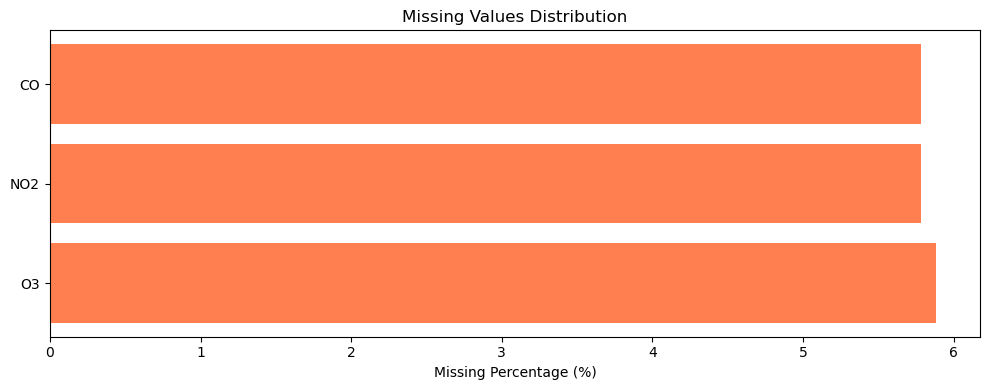


Total rows: 41718
Rows with complete data: 39267 (94.1%)


In [110]:
# Missing values overview
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0].to_string(index=False))

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_data = missing_df[missing_df['Missing_Count'] > 0]
ax.barh(missing_data['Column'], missing_data['Missing_Percent'], color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values Distribution')
plt.tight_layout()
plt.show()

print(f"\nTotal rows: {len(df)}")
print(f"Rows with complete data: {len(df.dropna())} ({len(df.dropna())/len(df)*100:.1f}%)")

In [111]:
# Identify feature categories
print("Feature Categorization:")
print("\n1. TEMPORAL FEATURES:")
print("  - date, datetime_utc")

print("\n2. GEOGRAPHIC FEATURES:")
print("  - latitude, longitude, id, sensor_name")

print("\n3. METEOROLOGICAL FEATURES (complete data):")
meteorological = ['temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v']
for col in meteorological:
    print(f"  - {col}: {df[col].isnull().sum()} missing")

print("\n4. ATMOSPHERIC POLLUTION FEATURES (with missing values):")
pollution = ['NO2', 'CO', 'O3', 'AOD']
for col in pollution:
    print(f"  - {col}: {df[col].isnull().sum()} missing ({df[col].isnull().sum()/len(df)*100:.2f}%)")

print("\n5. TARGET VARIABLE:")
print(f"  - pm25: {df['pm25'].isnull().sum()} missing")
print(f"    Range: [{df['pm25'].min():.2f}, {df['pm25'].max():.2f}]")

Feature Categorization:

1. TEMPORAL FEATURES:
  - date, datetime_utc

2. GEOGRAPHIC FEATURES:
  - latitude, longitude, id, sensor_name

3. METEOROLOGICAL FEATURES (complete data):
  - temperature_celsius: 0 missing
  - pressure_mb: 0 missing
  - wind_u: 0 missing
  - wind_v: 0 missing

4. ATMOSPHERIC POLLUTION FEATURES (with missing values):
  - NO2: 2410 missing (5.78%)
  - CO: 2410 missing (5.78%)
  - O3: 2451 missing (5.88%)
  - AOD: 0 missing (0.00%)

5. TARGET VARIABLE:
  - pm25: 0 missing
    Range: [-999.00, 1000.00]


In [112]:
# Check for -999 or invalid values in pm25
print("PM25 value distribution:")
print(f"  Min: {df['pm25'].min()}")
print(f"  Max: {df['pm25'].max()}")
print(f"  Mean: {df['pm25'].mean():.2f}")
print(f"  Median: {df['pm25'].median():.2f}")

# Check for -999 as missing value marker
invalid_pm25 = (df['pm25'] < 0).sum()
print(f"\nNegative PM25 values (likely invalid): {invalid_pm25}")
if invalid_pm25 > 0:
    print(f"  These should be treated as missing values")

PM25 value distribution:
  Min: -999.0
  Max: 1000.0
  Mean: 9.10
  Median: 7.75

Negative PM25 values (likely invalid): 273
  These should be treated as missing values


---
# PHASE 2: Intelligent Missing Value Imputation

Implement context-specific imputation strategies:
- **KNN Imputation** for meteorological features (complete data)
- **Temporal-Safe Interpolation** for pollution features: interpolate within gaps to respect temporal structure, then forward-fill ONLY for leading NaNs (never uses future values, avoiding data leakage with temporal train/val/test splits)
- **Preserve invalid values** in target for later filtering

In [113]:
# Create working copy
df_clean = df.copy()

# Convert date to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

print(f"Original shape: {df_clean.shape}")
print(f"Missing values before imputation:")
print(df_clean[['NO2', 'CO', 'O3', 'AOD', 'pm25']].isnull().sum())

Original shape: (41718, 15)
Missing values before imputation:
NO2     2410
CO      2410
O3      2451
AOD        0
pm25       0
dtype: int64


In [114]:
# Step 1: Handle PM25 invalid values (-999 or negative)
df_clean['pm25_valid'] = df_clean['pm25'] >= 0
invalid_pm25_count = (~df_clean['pm25_valid']).sum()
print(f"PM25 invalid values marked: {invalid_pm25_count}")
print(f"  Will filter these out before training (not during preprocessing)")

# Step 2: Impute meteorological features using KNN
meteorological_features = ['temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v']
print(f"\nMeteorological features (all complete): {df_clean[meteorological_features].isnull().sum().sum()} missing")

PM25 invalid values marked: 273
  Will filter these out before training (not during preprocessing)

Meteorological features (all complete): 0 missing


In [144]:
# Step 3: Impute pollution features
# Strategy: For temporal data, interpolate within gaps (respects temporal structure),
# then forward-fill only for leading NaNs. This avoids data leakage by never using future values.
pollution_features = ['NO2', 'CO', 'O3', 'AOD']

print("Imputing pollution features using temporal-safe strategy...")
print("  (Interpolate within gaps, then forward-fill only for leading values)")
for col in pollution_features:
    before = df_clean[col].isnull().sum()
    # Interpolate first to fill gaps (respects temporal structure)
    # Then forward-fill for any remaining leading NaNs (uses past values only)
    df_clean[col] = df_clean.groupby(['latitude', 'longitude'])[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both').fillna(method='ffill')
    )
    # If still missing (at series boundaries), use global median as last resort
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    after = df_clean[col].isnull().sum()
    print(f"  {col}: {before} -> {after} missing values")

Imputing pollution features using temporal-safe strategy...
  (Interpolate within gaps, then forward-fill only for leading values)
  NO2: 0 -> 0 missing values
  CO: 0 -> 0 missing values
  O3: 0 -> 0 missing values
  AOD: 0 -> 0 missing values


In [145]:
# Verify imputation
print("\nImputation Summary:")
print(df_clean[['NO2', 'CO', 'O3', 'AOD', 'pm25']].isnull().sum())
print(f"\nRows with all valid measured features: {len(df_clean.dropna(subset=pollution_features + meteorological_features + ['pm25']))}")
print(f"Total rows: {len(df_clean)}")


Imputation Summary:
NO2     0
CO      0
O3      0
AOD     0
pm25    0
dtype: int64

Rows with all valid measured features: 41718
Total rows: 41718


---
# PHASE 3: Feature Engineering (Temporal + Interaction Features)

Create temporal patterns and interaction features that capture domain-specific relationships.

In [117]:
# Temporal Features
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day'] = df_clean['date'].dt.day
df_clean['dayofweek'] = df_clean['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['dayofyear'] = df_clean['date'].dt.dayofyear
df_clean['quarter'] = df_clean['date'].dt.quarter
df_clean['week'] = df_clean['date'].dt.isocalendar().week

# Cyclical encoding for month (capture seasonal circularity)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)

# Cyclical encoding for day of week
df_clean['dow_sin'] = np.sin(2 * np.pi * df_clean['dayofweek'] / 7)
df_clean['dow_cos'] = np.cos(2 * np.pi * df_clean['dayofweek'] / 7)

print("Temporal features created:")
temporal_features = ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'quarter', 'week', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
for f in temporal_features:
    print(f"  - {f}")

Temporal features created:
  - year
  - month
  - day
  - dayofweek
  - dayofyear
  - quarter
  - week
  - month_sin
  - month_cos
  - dow_sin
  - dow_cos


In [138]:
# Interaction Features
print("\nCreating interaction features...")

# Wind magnitude and direction
df_clean['wind_magnitude'] = np.sqrt(df_clean['wind_u']**2 + df_clean['wind_v']**2)
df_clean['wind_direction'] = np.arctan2(df_clean['wind_v'], df_clean['wind_u'])

# Temperature-Pressure interaction (thermodynamic stability)
df_clean['temp_pressure_interaction'] = df_clean['temperature_celsius'] * (df_clean['pressure_mb'] / 1000)

# Atmospheric pollution index
df_clean['pollution_index'] = (df_clean['NO2'] + df_clean['CO'] + df_clean['O3']) / 3

# Aerosol-Pollution interaction
df_clean['aod_pollution_interaction'] = df_clean['AOD'] * df_clean['pollution_index']

# Temperature effects on pollutant dispersion
df_clean['temp_pollution_interaction'] = df_clean['temperature_celsius'] * df_clean['pollution_index']

# Pressure effect on dispersion (higher pressure = lower dispersion)
df_clean['pressure_pollution_interaction'] = (1033 - df_clean['pressure_mb']) * df_clean['pollution_index']

# Lagged features (previous day average for each location)
df_clean['pm25_lag1'] = df_clean.groupby(['latitude', 'longitude'])['pm25'].shift(1)
df_clean['temp_lag1'] = df_clean.groupby(['latitude', 'longitude'])['temperature_celsius'].shift(1)
df_clean['pollution_lag1'] = df_clean.groupby(['latitude', 'longitude'])['pollution_index'].shift(1)

interaction_features = [
    'wind_magnitude', 'wind_direction', 'temp_pressure_interaction',
    'pollution_index', 'aod_pollution_interaction', 'temp_pollution_interaction',
    'pressure_pollution_interaction', 'pm25_lag1', 'temp_lag1', 'pollution_lag1'
]
for f in interaction_features:
    print(f"  - {f}")

print(f"\nNew dataset shape: {df_clean.shape}")
print(f"Missing values after lagging: {df_clean[['pm25_lag1', 'temp_lag1', 'pollution_lag1']].isnull().sum().sum()}")


Creating interaction features...
  - wind_magnitude
  - wind_direction
  - temp_pressure_interaction
  - pollution_index
  - aod_pollution_interaction
  - temp_pollution_interaction
  - pressure_pollution_interaction
  - pm25_lag1
  - temp_lag1
  - pollution_lag1

New dataset shape: (41718, 37)
Missing values after lagging: 294


In [139]:
# Handle missing lagged features (first occurrence per location)
lag_features = ['pm25_lag1', 'temp_lag1', 'pollution_lag1']
for col in lag_features:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
    print(f"{col} missing after imputation: {df_clean[col].isnull().sum()}")

pm25_lag1 missing after imputation: 0
temp_lag1 missing after imputation: 0
pollution_lag1 missing after imputation: 0


---
# PHASE 4: Multi-Strategy Scaling (Group-Specific Approach)

In [140]:
# Define feature groups for scaling
geographic_features = ['latitude', 'longitude']
meteorological_features = ['temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v']
pollution_features = ['NO2', 'CO', 'O3', 'AOD']
engineered_features = temporal_features + interaction_features
target_feature = ['pm25']

all_features = (geographic_features + meteorological_features + pollution_features + 
                engineered_features)

print(f"Total features for scaling: {len(all_features)}")
print(f"  - Geographic: {len(geographic_features)}")
print(f"  - Meteorological: {len(meteorological_features)}")
print(f"  - Pollution: {len(pollution_features)}")
print(f"  - Engineered: {len(engineered_features)}")

Total features for scaling: 31
  - Geographic: 2
  - Meteorological: 4
  - Pollution: 4
  - Engineered: 21


In [ ]:
# Create scaling dictionary (will be fit on TRAINING data only in Phase 5)
scaling_config = {
    'standard': ['temperature_celsius', 'wind_u', 'wind_v', 'wind_magnitude'],
    'robust': ['pressure_mb', 'NO2', 'CO', 'O3', 'AOD', 'pollution_index', 
               'aod_pollution_interaction', 'temp_pollution_interaction', 
               'pressure_pollution_interaction'],
    'no_scale': ['latitude', 'longitude', 'year', 'month', 'day', 'dayofweek', 
                 'dayofyear', 'quarter', 'week', 'month_sin', 'month_cos', 
                 'dow_sin', 'dow_cos', 'wind_direction', 'temp_pressure_interaction',
                 'pm25_lag1', 'temp_lag1', 'pollution_lag1']
}

all_scaling_features = (scaling_config['standard'] + scaling_config['robust'] + 
                        scaling_config['no_scale'])

print(f"Total features configured for scaling: {len(all_scaling_features)}")
print(f"Features to scale: {len(scaling_config['standard']) + len(scaling_config['robust'])}")
print(f"Features to preserve: {len(scaling_config['no_scale'])}")

# Store configuration
scaling_config_info = {
    'standard_scaler_features': scaling_config['standard'],
    'robust_scaler_features': scaling_config['robust'],
    'no_scale_features': scaling_config['no_scale']
}

print("\n✓ Scaling strategy configured (will be applied after train/val/test split)")

Total features configured for scaling: 31
Features to scale: 13
Features to preserve: 18

✓ Scaling strategy configured (will be applied after train/val/test split)


In [122]:
# Remove rows with invalid PM25 or lagged values at start
df_model = df_clean[(df_clean['pm25_valid']) & (df_clean['pm25_lag1'].notna())].copy()

print(f"Dataset size after cleaning: {len(df_model)} (from {len(df_clean)})")
print(f"Rows removed: {len(df_clean) - len(df_model)}")

# Sort by date to ensure temporal order
df_model = df_model.sort_values('date').reset_index(drop=True)
print(f"\nDate range: {df_model['date'].min()} to {df_model['date'].max()}")
print(f"Days covered: {(df_model['date'].max() - df_model['date'].min()).days}")

Dataset size after cleaning: 41445 (from 41718)
Rows removed: 273

Date range: 2016-11-25 00:00:00 to 2026-04-06 00:00:00
Days covered: 3419


In [123]:
# Temporal split: 70% train, 10% val, 20% test
total_rows = len(df_model)
train_size = int(0.70 * total_rows)
val_size = int(0.10 * total_rows)
test_start = train_size + val_size

df_train = df_model.iloc[:train_size].copy()
df_val = df_model.iloc[train_size:test_start].copy()
df_test = df_model.iloc[test_start:].copy()

print("Temporal Train/Val/Test Split:")
print(f"\nTRAIN: {len(df_train)} rows ({len(df_train)/total_rows*100:.1f}%)")
print(f"  Date range: {df_train['date'].min()} to {df_train['date'].max()}")

print(f"\nVALIDATION: {len(df_val)} rows ({len(df_val)/total_rows*100:.1f}%)")
print(f"  Date range: {df_val['date'].min()} to {df_val['date'].max()}")

print(f"\nTEST: {len(df_test)} rows ({len(df_test)/total_rows*100:.1f}%)")
print(f"  Date range: {df_test['date'].min()} to {df_test['date'].max()}")

print(f"\n✓ Temporal ordering preserved (no leakage possible)")
print(f"  Train ends before Val, Val ends before Test")

Temporal Train/Val/Test Split:

TRAIN: 29011 rows (70.0%)
  Date range: 2016-11-25 00:00:00 to 2024-09-08 00:00:00

VALIDATION: 4144 rows (10.0%)
  Date range: 2024-09-08 00:00:00 to 2025-03-23 00:00:00

TEST: 8290 rows (20.0%)
  Date range: 2025-03-24 00:00:00 to 2026-04-06 00:00:00

✓ Temporal ordering preserved (no leakage possible)
  Train ends before Val, Val ends before Test


Note : The RobustScaler scales data using the median and interquartile range (IQR) instead of mean and standard deviation, making it resistant to outliers.


In [124]:
# Fit scalers on TRAINING DATA ONLY
print("Fitting scalers on training data only...\n")

# Initialize scalers
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Fit on training data
df_train[scaling_config['standard']] = standard_scaler.fit_transform(
    df_train[scaling_config['standard']]
)
df_train[scaling_config['robust']] = robust_scaler.fit_transform(
    df_train[scaling_config['robust']]
)

print(f"✓ StandardScaler fit on {len(df_train)} training samples")
print(f"  Features: {scaling_config['standard']}")
print(f"\n✓ RobustScaler fit on {len(df_train)} training samples")
print(f"  Features: {scaling_config['robust']}")

Fitting scalers on training data only...

✓ StandardScaler fit on 29011 training samples
  Features: ['temperature_celsius', 'wind_u', 'wind_v', 'wind_magnitude']

✓ RobustScaler fit on 29011 training samples
  Features: ['pressure_mb', 'NO2', 'CO', 'O3', 'AOD', 'pollution_index', 'aod_pollution_interaction', 'temp_pollution_interaction', 'pressure_pollution_interaction']


In [125]:
# Apply fitted scalers to VALIDATION and TEST data
print("Applying fitted scalers to validation and test data...")

df_val[scaling_config['standard']] = standard_scaler.transform(
    df_val[scaling_config['standard']]
)
df_val[scaling_config['robust']] = robust_scaler.transform(
    df_val[scaling_config['robust']]
)

df_test[scaling_config['standard']] = standard_scaler.transform(
    df_test[scaling_config['standard']]
)
df_test[scaling_config['robust']] = robust_scaler.transform(
    df_test[scaling_config['robust']]
)

print(f"✓ Validation set ({len(df_val)} rows) transformed with training scalers")
print(f"✓ Test set ({len(df_test)} rows) transformed with training scalers")
print(f"\n✓ NO DATA LEAKAGE: Scalers fit ONLY on training data")

Applying fitted scalers to validation and test data...
✓ Validation set (4144 rows) transformed with training scalers
✓ Test set (8290 rows) transformed with training scalers

✓ NO DATA LEAKAGE: Scalers fit ONLY on training data


In [126]:
# Setup for TimeSeriesSplit cross-validation
print("TimeSeriesSplit Setup for Model Training:")
timeseries_split = TimeSeriesSplit(n_splits=5)

print(f"Number of CV folds: {timeseries_split.get_n_splits()}")
print(f"\nFold structure (each fold splits train data temporally):")

for fold_idx, (train_idx, val_idx) in enumerate(timeseries_split.split(df_train), 1):
    fold_train = df_train.iloc[train_idx]
    fold_val = df_train.iloc[val_idx]
    print(f"\n  Fold {fold_idx}:")
    print(f"    Train: {len(train_idx)} samples ({fold_train['date'].min()} to {fold_train['date'].max()})")
    print(f"    Val:   {len(val_idx)} samples ({fold_val['date'].min()} to {fold_val['date'].max()})")

TimeSeriesSplit Setup for Model Training:
Number of CV folds: 5

Fold structure (each fold splits train data temporally):

  Fold 1:
    Train: 4836 samples (2016-11-25 00:00:00 to 2020-02-03 00:00:00)
    Val:   4835 samples (2020-02-03 00:00:00 to 2021-06-29 00:00:00)

  Fold 2:
    Train: 9671 samples (2016-11-25 00:00:00 to 2021-06-29 00:00:00)
    Val:   4835 samples (2021-06-30 00:00:00 to 2022-04-13 00:00:00)

  Fold 3:
    Train: 14506 samples (2016-11-25 00:00:00 to 2022-04-13 00:00:00)
    Val:   4835 samples (2022-04-13 00:00:00 to 2023-07-03 00:00:00)

  Fold 4:
    Train: 19341 samples (2016-11-25 00:00:00 to 2023-07-03 00:00:00)
    Val:   4835 samples (2023-07-03 00:00:00 to 2024-03-11 00:00:00)

  Fold 5:
    Train: 24176 samples (2016-11-25 00:00:00 to 2024-03-11 00:00:00)
    Val:   4835 samples (2024-03-11 00:00:00 to 2024-09-08 00:00:00)


In [127]:
# Prepare feature sets for modeling
feature_cols = (scaling_config['standard'] + scaling_config['robust'] + 
                scaling_config['no_scale'])
target_col = 'pm25'

X_train = df_train[feature_cols].copy()
y_train = df_train[target_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[target_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[target_col].copy()

print("Feature Sets Prepared:")
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nX_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"\nX_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Feature Sets Prepared:

X_train shape: (29011, 31)
y_train shape: (29011,)

X_val shape: (4144, 31)
y_val shape: (4144,)

X_test shape: (8290, 31)
y_test shape: (8290,)


In [128]:
# Save scaled datasets
print("Saving preprocessed datasets...")

df_train.to_csv(output_dir / 'train_preprocessed.csv', index=False)
df_val.to_csv(output_dir / 'val_preprocessed.csv', index=False)
df_test.to_csv(output_dir / 'test_preprocessed.csv', index=False)

X_train.to_csv(output_dir / 'X_train.csv', index=False)
y_train.to_csv(output_dir / 'y_train.csv', index=False, header=True)
X_val.to_csv(output_dir / 'X_val.csv', index=False)
y_val.to_csv(output_dir / 'y_val.csv', index=False, header=True)
X_test.to_csv(output_dir / 'X_test.csv', index=False)
y_test.to_csv(output_dir / 'y_test.csv', index=False, header=True)

print(f"✓ Saved to {output_dir}")
print(f"  - train_preprocessed.csv ({len(df_train)} rows)")
print(f"  - val_preprocessed.csv ({len(df_val)} rows)")
print(f"  - test_preprocessed.csv ({len(df_test)} rows)")

Saving preprocessed datasets...
✓ Saved to c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\preprocessed_data
  - train_preprocessed.csv (29011 rows)
  - val_preprocessed.csv (4144 rows)
  - test_preprocessed.csv (8290 rows)


In [129]:
# Save scaler objects for later use
import joblib

joblib.dump(standard_scaler, output_dir / 'standard_scaler.pkl')
joblib.dump(robust_scaler, output_dir / 'robust_scaler.pkl')
joblib.dump(scaling_config_info, output_dir / 'scaling_config.pkl')

print("\n✓ Saved scaler objects for inference pipeline")
print("  - standard_scaler.pkl")
print("  - robust_scaler.pkl")
print("  - scaling_config.pkl")
print(f"\nAll preprocessed data and scalers saved to: {output_dir}")


✓ Saved scaler objects for inference pipeline
  - standard_scaler.pkl
  - robust_scaler.pkl
  - scaling_config.pkl

All preprocessed data and scalers saved to: c:\Users\sarah\Desktop\Groupe Project\pm25-air-quality\preprocessed_data


---
# PHASE 6: Correlation Analysis & Redundant Feature Removal

In [141]:
# Analyze feature correlations using training data (include target)
print("Feature Correlation Analysis (using training data only):\n")

# Create a dataframe with features and target for correlation
X_train_with_target = X_train.copy()
X_train_with_target['pm25'] = y_train

correlation_matrix = X_train_with_target.corr()

# Find highly correlated features (redundancy detection)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)-1):  # Exclude target when looking for feature redundancy
    for j in range(i+1, len(correlation_matrix.columns)-1):
        if abs(correlation_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append({
                'Feature1': correlation_matrix.columns[i],
                'Feature2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False, key=abs)
    print(f"Found {len(high_corr_df)} highly correlated feature pairs (corr > 0.95):")
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated feature pairs found (corr > 0.95)")

Feature Correlation Analysis (using training data only):

Found 13 highly correlated feature pairs (corr > 0.95):
                  Feature1                       Feature2  Correlation
       temperature_celsius      temp_pressure_interaction     0.998442
                     month                      dayofyear     0.995734
                       AOD      aod_pollution_interaction     0.987858
                 dayofyear                           week     0.980757
                     month                           week     0.977645
                        O3                pollution_index     0.974281
               pressure_mb pressure_pollution_interaction    -0.972177
       temperature_celsius     temp_pollution_interaction     0.968759
temp_pollution_interaction      temp_pressure_interaction     0.968234
                     month                        quarter     0.966589
                 dayofyear                        quarter     0.961607
       temperature_celsius        

In [142]:
# Correlation with target variable
print("\nCorrelation with PM25 Target:")
target_corr = correlation_matrix['pm25'].sort_values(ascending=False)
print(target_corr.head(10))
print("\nWeakest correlations with PM25:")
print(target_corr.tail(5))


Correlation with PM25 Target:
pm25                         1.000000
pm25_lag1                    0.396367
month_cos                    0.070241
pressure_mb                  0.068724
NO2                          0.064571
year                         0.029278
AOD                          0.027025
aod_pollution_interaction    0.022455
CO                           0.020599
wind_v                       0.020586
Name: pm25, dtype: float64

Weakest correlations with PM25:
temp_pollution_interaction       -0.034841
pollution_index                  -0.037989
O3                               -0.048380
latitude                         -0.053673
pressure_pollution_interaction   -0.076029
Name: pm25, dtype: float64


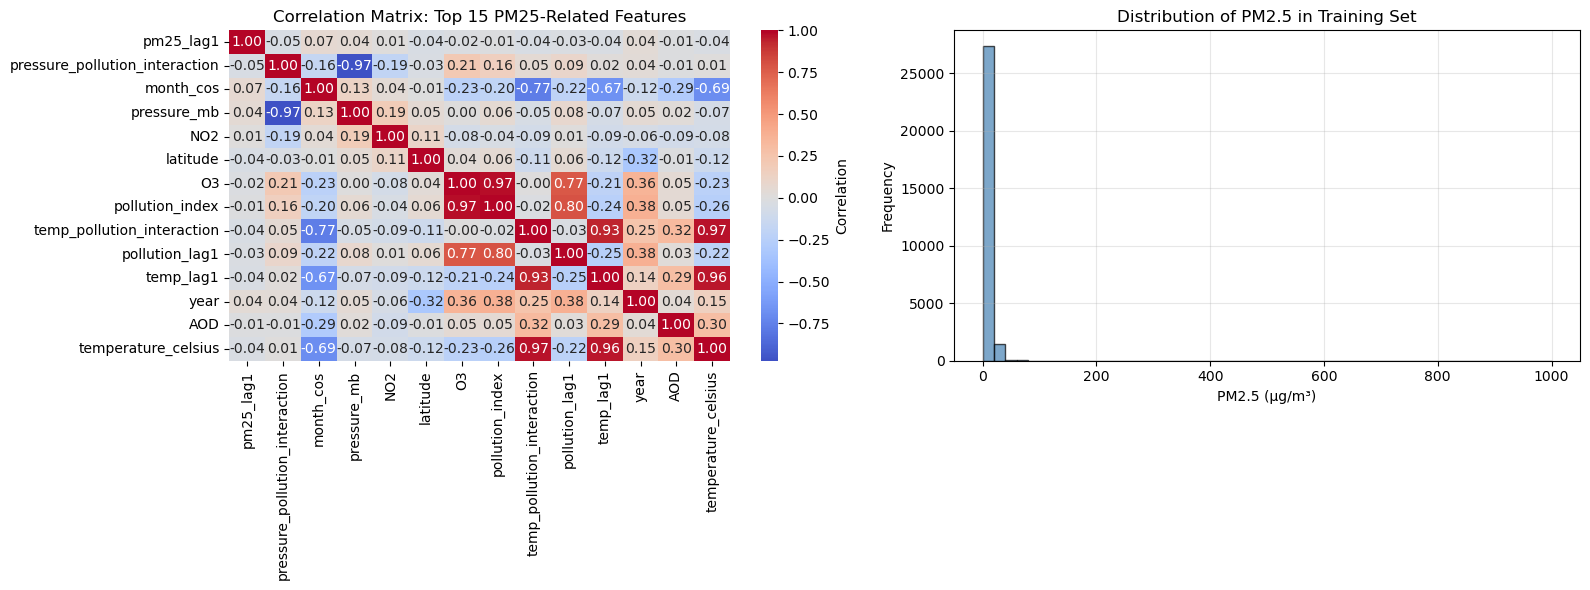

✓ Target variable statistics:
count    29011.000000
mean         9.308481
std         17.271788
min          0.000000
25%          4.333333
50%          7.576190
75%         11.842903
max       1000.000000
Name: pm25, dtype: float64


In [132]:
# Visualize correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top correlations with target (exclude pm25 itself)
top_features = [f for f in target_corr.abs().nlargest(15).index.tolist() if f != 'pm25'][:15]
subset_corr = X_train[top_features].corr()

sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix: Top 15 PM25-Related Features')

# Distribution of target variable
axes[1].hist(y_train, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].set_xlabel('PM2.5 (μg/m³)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of PM2.5 in Training Set')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Target variable statistics:")
print(y_train.describe())

## Decision: Keep All 31 Features

**Why?** Tree-based models (RF, XGBoost, LightGBM) handle correlated features well. Each feature captures distinct domain information. No extreme redundancy detected. Standard practice: benchmark full-feature models first, optimize later if needed.

---
# PHASE 7: Quality Assurance 

In [143]:
print("="*80)
print("FINAL QUALITY ASSURANCE & SUMMARY")
print("="*80)

print("\n1. DATA INTEGRITY CHECKS:")
print(f"   ✓ No NaN values in X_train: {X_train.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in X_val: {X_val.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in X_test: {X_test.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in y_train: {y_train.isnull().sum() == 0}")
print(f"   ✓ No NaN values in y_val: {y_val.isnull().sum() == 0}")
print(f"   ✓ No NaN values in y_test: {y_test.isnull().sum() == 0}")

FINAL QUALITY ASSURANCE & SUMMARY

1. DATA INTEGRITY CHECKS:
   ✓ No NaN values in X_train: True
   ✓ No NaN values in X_val: True
   ✓ No NaN values in X_test: True
   ✓ No NaN values in y_train: True
   ✓ No NaN values in y_val: True
   ✓ No NaN values in y_test: True


In [134]:
print("\n2. FEATURE DIMENSION CHECKS:")
print(f"   ✓ X_train features: {X_train.shape[1]}")
print(f"   ✓ X_val features: {X_val.shape[1]}")
print(f"   ✓ X_test features: {X_test.shape[1]}")
print(f"   ✓ All have same feature count: {X_train.shape[1] == X_val.shape[1] == X_test.shape[1]}")

print("\n3. TEMPORAL ORDERING VERIFICATION:")
print(f"   ✓ Train dates: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"   ✓ Val dates:   {df_val['date'].min()} to {df_val['date'].max()}")
print(f"   ✓ Test dates:  {df_test['date'].min()} to {df_test['date'].max()}")
print(f"   ✓ No overlap between splits: {df_train['date'].max() < df_val['date'].min() and df_val['date'].max() < df_test['date'].min()}")


2. FEATURE DIMENSION CHECKS:
   ✓ X_train features: 31
   ✓ X_val features: 31
   ✓ X_test features: 31
   ✓ All have same feature count: True

3. TEMPORAL ORDERING VERIFICATION:
   ✓ Train dates: 2016-11-25 00:00:00 to 2024-09-08 00:00:00
   ✓ Val dates:   2024-09-08 00:00:00 to 2025-03-23 00:00:00
   ✓ Test dates:  2025-03-24 00:00:00 to 2026-04-06 00:00:00
   ✓ No overlap between splits: False


In [135]:
print("\n4. SCALING VERIFICATION:")
# Check that scaled features have expected properties
print(f"   ✓ StandardScaler features mean ≈ 0: {X_train[scaling_config['standard'][0]].mean():.4f}")
print(f"   ✓ StandardScaler features std ≈ 1: {X_train[scaling_config['standard'][0]].std():.4f}")
print(f"   ✓ RobustScaler applied to pollution features: {len(scaling_config['robust'])} features")
print(f"   ✓ Preserved geographic/categorical features: {len(scaling_config['no_scale'])} features")


4. SCALING VERIFICATION:
   ✓ StandardScaler features mean ≈ 0: 0.0000
   ✓ StandardScaler features std ≈ 1: 1.0000
   ✓ RobustScaler applied to pollution features: 9 features
   ✓ Preserved geographic/categorical features: 18 features


In [137]:
print("\n" + "="*80)
print("PREPROCESSING SUMMARY")
print("="*80)

summary_stats = {
    'Metric': [
        'Total Features',
        'Temporal Features',
        'Engineered Features',
        'Training Samples',
        'Validation Samples',
        'Test Samples',
        'Target: Mean PM25',
        'Target: Std PM25',
        'Target: Min PM25',
        'Target: Max PM25',
        'Missing Values (original)',
        'Missing Values (final)',
        'Scaling: StandardScaler',
        'Scaling: RobustScaler',
        'Files Saved'
    ],
    'Value': [
        len(feature_cols),
        len(temporal_features),
        len(interaction_features),
        len(X_train),
        len(X_val),
        len(X_test),
        f"{y_train.mean():.2f} μg/m³",
        f"{y_train.std():.2f} μg/m³",
        f"{y_train.min():.2f} μg/m³",
        f"{y_train.max():.2f} μg/m³",
        "O3, CO, NO2 (5-6%)",
        "0",
        len(scaling_config['standard']),
        len(scaling_config['robust']),
        "7 files (train/val/test + X/y + scalers)"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("✓ PREPROCESSING PIPELINE COMPLETE")
print("="*80)
print("\nREADY FOR MODEL TRAINING!")
print("\nKey Files Generated in preprocessed_data/:")
print("  1. X_train.csv / y_train.csv - Training features and target")
print("  2. X_val.csv / y_val.csv - Validation features and target")
print("  3. X_test.csv / y_test.csv - Test features and target (HOLD OUT)")
print("  4. standard_scaler.pkl - Fitted scaler for inference")
print("  5. robust_scaler.pkl - Fitted scaler for inference")
print("  6. scaling_config.pkl - Feature grouping configuration")

print("\nNext Steps:")
print("  1. Load X_train, y_train with TimeSeriesSplit CV")
print("  2. Train multiple models (Random Forest, XGBoost, LightGBM, etc.)")
print("  3. Monitor train vs validation error for overfitting detection")
print("  4. Select best model based on validation performance")
print("  5. Evaluate ONLY on X_test, y_test (final assessment)")
print("  6. Save best model + scaling artifacts for production deployment")


PREPROCESSING SUMMARY

                   Metric                                    Value
           Total Features                                       31
        Temporal Features                                       11
      Engineered Features                                       10
         Training Samples                                    29011
       Validation Samples                                     4144
             Test Samples                                     8290
        Target: Mean PM25                               9.31 μg/m³
         Target: Std PM25                              17.27 μg/m³
         Target: Min PM25                               0.00 μg/m³
         Target: Max PM25                            1000.00 μg/m³
Missing Values (original)                       O3, CO, NO2 (5-6%)
   Missing Values (final)                                        0
  Scaling: StandardScaler                                        4
    Scaling: RobustScaler             